In [29]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames
from dashsrc.plot_components.plots import plot_TrackFiringRate
from dashsrc.plot_components.plots import plot_unit_fr_stability


In [30]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [0,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min'] # ignore short sessions (10, 24,25)

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-02-17 15:08:13,463|DEBUG|48560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
Searching NAS for applicable sessions...================================================================================

Searching NAS for applicable sessions...================================================================================

2026-02-17 15:08:13,463|DEBUG|48560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-17 15:08:13,463|DEBUG|48560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-17 15:08:13,463|DEBUG|48560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-17 15:08:13,500|DEBUG|48560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 exc

In [31]:
# firing rates and behavior data
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
# fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
#fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
#fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
t0_events = analytics.get_analytics('TrialWiseT0Events40ms', session_names=session_names)
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

# ensamble related data
t0_ens = analytics.get_analytics('EnsembleT0Projection', session_names=session_names)
# ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
# ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
# ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
# ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-02-17 15:08:13,701|DEBUG|48560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-02-17 15:08:13,701|DEBUG|48560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-17 15:08:13,701|DEBUG|48560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-17 15:08:13,701|DEBUG|48560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-17 15:08:14,025|DEBUG|48560|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 30 

In [32]:

interval_cols = [c for c in t0_events.columns if 'interval' in c]

for col in interval_cols:
    #print(f"{col}: {t0_events[col].notna().sum()} non-NA entries")
    x = t0_events[t0_events[col].notna()]
    mean_length = (x[col].array.right - x[col].array.left)
    mean_length = mean_length.to_numpy().astype(float).mean()
    print(f"Mean length of {col}: {mean_length:.2f} microseconds")
#x['R2_entry_interval'].array.right

Mean length of pre_cue_interval: 200000.00 microseconds
Mean length of nextto_cue_interval: 200000.00 microseconds
Mean length of cue_entry_interval: 1600000.00 microseconds
Mean length of R1_entry_interval: 1800000.00 microseconds
Mean length of R2_entry_interval: 1600000.00 microseconds


In [34]:
plot_col = "Assembly012"

df_plot = t0_ens.reset_index().copy()
df_plot = df_plot[df_plot['cue']==2]

required_cols = {"session_id", "interval_name", plot_col}
missing_cols = required_cols.difference(df_plot.columns)

df_plot = df_plot.dropna(subset=["session_id", "interval_name", plot_col])

df_plot["session_id"] = df_plot["session_id"].astype(str)
df_plot["session_dt"] = pd.to_datetime(
    df_plot["session_id"], format="%Y-%m-%d_%H-%M", errors="coerce"
)

agg = (
    df_plot.groupby(["session_id", "interval_name"], as_index=False)[plot_col]
    .mean()
)

interval_order = sorted(agg["interval_name"].unique().tolist())

session_order = (
    df_plot[["session_id", "session_dt"]]
    .drop_duplicates()
    .sort_values(["session_dt", "session_id"])
    ["session_id"]
    .tolist()
)
session_date_labels = [s.split('_')[0] for s in session_order]

agg["session_id"] = pd.Categorical(
    agg["session_id"], categories=session_order, ordered=True
)
agg["interval_name"] = pd.Categorical(
    agg["interval_name"], categories=interval_order, ordered=True
)
agg = agg.sort_values(["session_id", "interval_name"])

counts_per_session = agg.groupby("session_id", observed=False)["interval_name"].nunique()
print(f"Unique interval_name values: {interval_order}")
print(f"Expected values per session: {len(interval_order)}")
print(f"Sessions missing interval(s): {(counts_per_session < len(interval_order)).sum()}")

display(agg.pivot(index="session_id", columns="interval_name", values=plot_col).head())

fig = px.line(
    agg,
    x="session_id",
    y=plot_col,
    color="interval_name",
    markers=True,
    labels={
        "session_id": "Session ID",
        plot_col: f"Mean {plot_col}",
        "interval_name": "Interval",
    },
    title=f"{plot_col} over sessions by interval_name Cue2",
)
fig.update_xaxes(
    tickmode="array",
    tickvals=session_order,
    ticktext=session_date_labels,
    tickangle=45,
    categoryorder="array",
    categoryarray=session_order,
)
fig.update_layout(template="plotly_white")
fig.show()


Unique interval_name values: ['R1_entry_interval', 'R2_entry_interval', 'cue_entry_interval', 'nextto_cue_interval', 'pre_cue_interval']
Expected values per session: 5
Sessions missing interval(s): 0


interval_name,R1_entry_interval,R2_entry_interval,cue_entry_interval,nextto_cue_interval,pre_cue_interval
session_id,,,,,
2024-11-14_16-40,0.323466,0.344134,0.196427,0.233396,0.113649
2024-11-15_15-48,0.884099,1.179659,0.693319,0.704617,0.649821
2024-11-20_17-46,0.428599,0.442395,0.354652,0.409301,0.500873
2024-11-21_17-22,0.607827,0.669166,0.501700,0.922195,0.597954
2024-11-25_16-25,0.271999,0.378733,0.136549,0.413062,-0.068578


In [35]:
# Choice-conditioned view: cue1 compares choice_R1, cue2 compares choice_R2
plot_col = "Assembly012"

choice_df = t0_ens.reset_index().copy()

required_cols = {"session_id", "trial_id", "cue", "choice_R1", "choice_R2", plot_col}
missing_cols = required_cols.difference(choice_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in t0_ens: {sorted(missing_cols)}")

choice_df = choice_df.dropna(subset=["session_id", "trial_id", "cue", plot_col])
choice_df = choice_df[choice_df["cue"].isin([1, 2])].copy()

trial_level = (
    choice_df.groupby(["session_id", "trial_id", "cue"], as_index=False)[plot_col]
    .mean()
)

trial_choices = (
    choice_df.groupby(["session_id", "trial_id", "cue"], as_index=False)[["choice_R1", "choice_R2"]]
    .first()
)

trial_level = trial_level.merge(
    trial_choices, on=["session_id", "trial_id", "cue"], how="left"
)

trial_level["stopped_at_cued_reward"] = np.where(
    trial_level["cue"] == 1,
    trial_level["choice_R1"],
    np.where(trial_level["cue"] == 2, trial_level["choice_R2"], np.nan),
)

trial_level = trial_level.dropna(subset=["stopped_at_cued_reward"]).copy()
trial_level["stopped_at_cued_reward"] = trial_level["stopped_at_cued_reward"].astype(bool)
trial_level["choice_label"] = np.where(
    trial_level["stopped_at_cued_reward"],
    "Stopped at cued reward",
    "Did NOT stop at cued reward",
)
trial_level["cue_label"] = trial_level["cue"].map({1: "Cue 1", 2: "Cue 2"})

trial_level["session_id"] = trial_level["session_id"].astype(str)
trial_level["session_dt"] = pd.to_datetime(
    trial_level["session_id"], format="%Y-%m-%d_%H-%M", errors="coerce"
)
session_order = (
    trial_level[["session_id", "session_dt"]]
    .drop_duplicates()
    .sort_values(["session_dt", "session_id"])
    ["session_id"]
    .tolist()
)
session_date_labels = [s.split('_')[0] for s in session_order]

summary = (
    trial_level.groupby(["session_id", "cue_label", "choice_label"], as_index=False)
    .agg(mean_activation=(plot_col, "mean"), n_trials=("trial_id", "nunique"))
)

summary["session_id"] = pd.Categorical(
    summary["session_id"], categories=session_order, ordered=True
)
summary = summary.sort_values(["session_id", "cue_label", "choice_label"])

display(summary.head())

fig_choice = px.line(
    summary,
    x="session_id",
    y="mean_activation",
    color="choice_label",
    facet_col="cue_label",
    markers=True,
    category_orders={
        "session_id": session_order,
        "cue_label": ["Cue 1", "Cue 2"],
    },
    hover_data={"n_trials": True},
    labels={
        "session_id": "Session ID",
        "mean_activation": f"Trial-mean {plot_col}",
        "choice_label": "Choice vs cue",
        "cue_label": "Cue",
    },
    title=f"{plot_col}: cue-conditioned choice effect over sessions",
)
fig_choice.for_each_annotation(lambda a: a.update(text=a.text.replace("cue_label=", "")))
fig_choice.update_xaxes(
    tickmode="array",
    tickvals=session_order,
    ticktext=session_date_labels,
    tickangle=45,
    categoryorder="array",
    categoryarray=session_order,
)
fig_choice.update_layout(template="plotly_white")
fig_choice.show()


,session_id,cue_label,choice_label,mean_activation,n_trials
0,2024-11-14_16-40,Cue 1,Did NOT stop at cued reward,0.273174,42
1,2024-11-14_16-40,Cue 1,Stopped at cued reward,0.372657,12
2,2024-11-14_16-40,Cue 2,Did NOT stop at cued reward,0.277654,45
3,2024-11-14_16-40,Cue 2,Stopped at cued reward,0.328659,3
4,2024-11-15_15-48,Cue 1,Did NOT stop at cued reward,0.933026,44


In [36]:
# Interval-resolved choice view: cue x interval x choice outcome
plot_col = "Assembly012"

interval_choice_df = t0_ens.reset_index().copy()

required_cols = {
    "session_id",
    "trial_id",
    "cue",
    "choice_R1",
    "choice_R2",
    "interval_name",
    plot_col,
}
missing_cols = required_cols.difference(interval_choice_df.columns)

interval_choice_df = interval_choice_df.dropna(
    subset=["session_id", "trial_id", "cue", "interval_name", plot_col]
)
interval_choice_df = interval_choice_df[interval_choice_df["cue"].isin([1, 2])].copy()

trial_interval = (
    interval_choice_df.groupby(
        ["session_id", "trial_id", "cue", "interval_name"], as_index=False
    )[plot_col]
    .mean()
)

trial_choices = (
    interval_choice_df.groupby(["session_id", "trial_id", "cue"], as_index=False)[
        ["choice_R1", "choice_R2"]
    ]
    .first()
)

trial_interval = trial_interval.merge(
    trial_choices, on=["session_id", "trial_id", "cue"], how="left"
)

r1_only = trial_interval["choice_R1"].eq(True) & ~trial_interval["choice_R2"].eq(True)
r2_only = trial_interval["choice_R2"].eq(True) & ~trial_interval["choice_R1"].eq(True)

trial_interval["choice_vs_cue"] = np.select(
    [
        (trial_interval["cue"] == 1) & r1_only,
        (trial_interval["cue"] == 1) & trial_interval["choice_R1"].eq(False),
        (trial_interval["cue"] == 2) & r2_only,
        (trial_interval["cue"] == 2) & trial_interval["choice_R2"].eq(False),
    ],
    [
        "Cued reward choice (expert)",
        "Non reward choice",
        "Cued reward choice (expert)",
        "Non reward choice",
    ],
    default="Other (incl. double stopping)",
)
trial_interval["cue_label"] = trial_interval["cue"].map({1: "Cue 1", 2: "Cue 2"})

trial_interval["session_id"] = trial_interval["session_id"].astype(str)
trial_interval["session_dt"] = pd.to_datetime(
    trial_interval["session_id"], format="%Y-%m-%d_%H-%M", errors="coerce"
)
session_order = (
    trial_interval[["session_id", "session_dt"]]
    .drop_duplicates()
    .sort_values(["session_dt", "session_id"])
    ["session_id"]
    .tolist()
)
session_date_labels = [s.split('_')[0] for s in session_order]
interval_order = sorted(trial_interval["interval_name"].astype(str).unique().tolist())

summary_interval = (
    trial_interval.groupby(
        ["session_id", "cue_label", "interval_name", "choice_vs_cue"],
        as_index=False,
    )
    .agg(mean_activation=(plot_col, "mean"), n_trials=("trial_id", "nunique"))
)

summary_interval["session_id"] = pd.Categorical(
    summary_interval["session_id"], categories=session_order, ordered=True
)
summary_interval["interval_name"] = pd.Categorical(
    summary_interval["interval_name"], categories=interval_order, ordered=True
)
summary_interval = summary_interval.sort_values(
    ["session_id", "interval_name", "cue_label", "choice_vs_cue"]
)

display(summary_interval.head())

fig_interval_choice = px.line(
    summary_interval,
    x="session_id",
    y="mean_activation",
    color="choice_vs_cue",
    facet_row="interval_name",
    facet_col="cue_label",
    markers=True,
    category_orders={
        "session_id": session_order,
        "cue_label": ["Cue 1", "Cue 2"],
        "interval_name": interval_order,
        "choice_vs_cue": [
            "Cued reward choice (expert)",
            "Non reward choice",
            "Other (incl. double stopping)",
        ],
    },

    color_discrete_map={
        "Cued reward choice (expert)": "green",
        "Non reward choice": "red",
        "Other (incl. double stopping)": "grey",
    },
    hover_data={"n_trials": True},
    labels={
        "session_id": "Session ID",
        "mean_activation": f"Trial-mean {plot_col}",
        "choice_vs_cue": "Choice outcome",
        "cue_label": "Cue",
        "interval_name": "Interval",
    },
    title=f"{plot_col}: interval-resolved choice effects over sessions",
)
fig_interval_choice.for_each_annotation(
    lambda a: a.update(
        text=a.text.replace("cue_label=", "").replace("interval_name=", "Interval: ")
    )
)
fig_interval_choice.update_xaxes(
    tickmode="array",
    tickvals=session_order,
    ticktext=session_date_labels,
    tickangle=45,
    categoryorder="array",
    categoryarray=session_order,
)
fig_interval_choice.update_layout(
    template="plotly_white",
    height=max(650, 250 * len(interval_order)),
    legend_title_text="Choice outcome",
)
fig_interval_choice.show()


,session_id,cue_label,interval_name,choice_vs_cue,mean_activation,n_trials
0,2024-11-14_16-40,Cue 1,R1_entry_interval,Cued reward choice (expert),0.451491,9
1,2024-11-14_16-40,Cue 1,R1_entry_interval,Non reward choice,0.302606,42
2,2024-11-14_16-40,Cue 1,R1_entry_interval,Other (incl. double stopping),0.590060,3
15,2024-11-14_16-40,Cue 2,R1_entry_interval,Cued reward choice (expert),0.405634,1
16,2024-11-14_16-40,Cue 2,R1_entry_interval,Non reward choice,0.310736,45


Selected 25 sessions
First: 2024-11-14_16-40 | Last: 2025-01-27_13-39


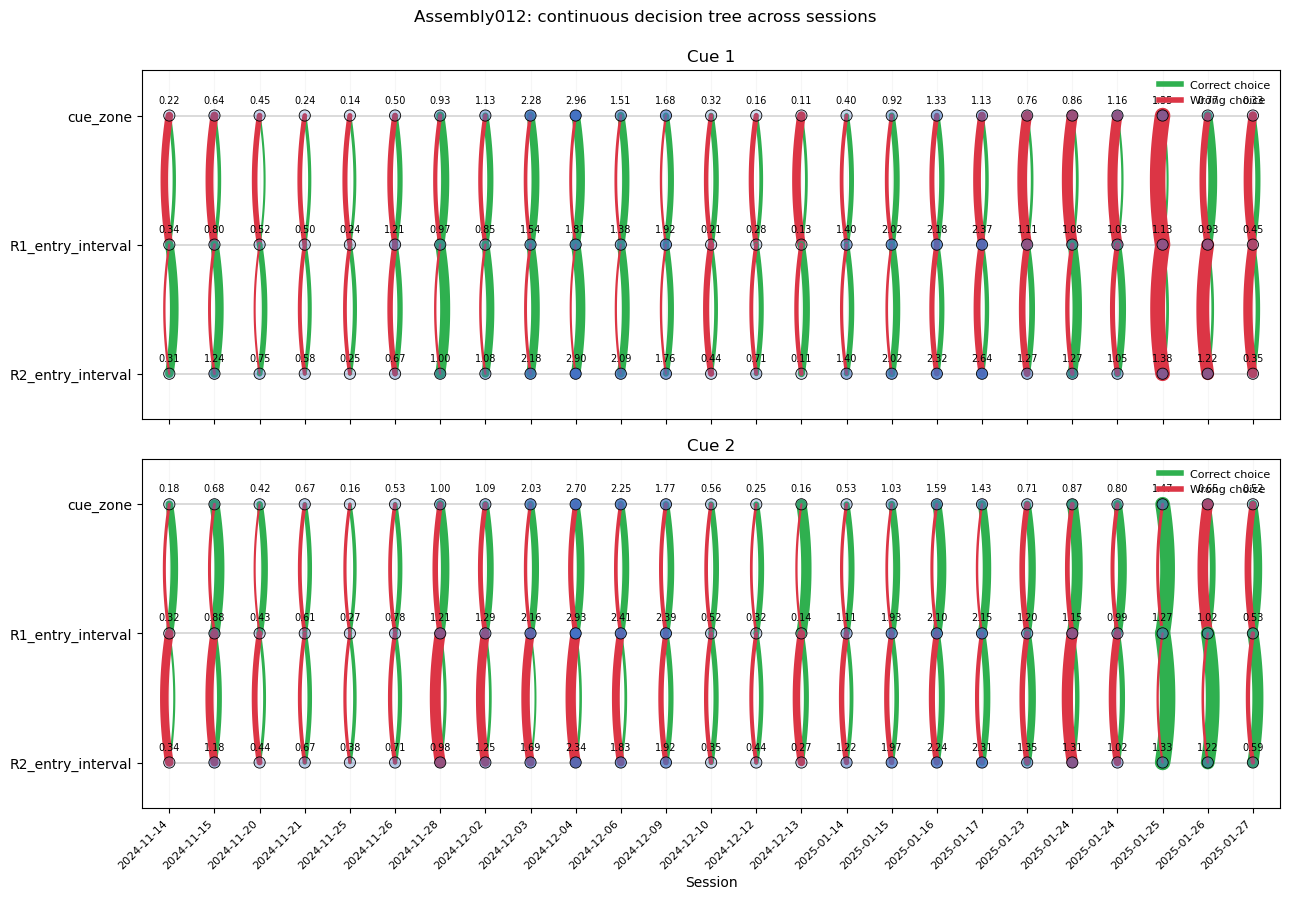

In [37]:
plot_col = "Assembly012"

selected_session_ids = None
# selected_session_ids = ["2024-11-14_16-40", "2024-11-15_15-48", "2024-11-20_17-46"]

# Option B: index range on chronologically sorted sessions (inclusive)
selected_session_index_range = (0, None)
# selected_session_index_range = (5, 12)


def _safe_mean(series):
    return float(series.mean()) if len(series) else np.nan


def _prepare_trial_level(df, activation_col="Assembly012"):
    required = {
        "session_id",
        "trial_id",
        "cue",
        "choice_R1",
        "choice_R2",
        "interval_name",
        activation_col,
    }

    work = df.reset_index().copy()
    missing = required.difference(work.columns)
    if missing:
        raise ValueError(f"Missing required columns in t0_ens: {sorted(missing)}")

    work = work.dropna(subset=["session_id", "trial_id", "cue", "interval_name", activation_col])
    work = work[work["cue"].isin([1, 2])].copy()

    cue_zone_parts = ["pre_cue_interval", "cue_entry_interval", "nextto_cue_interval"]
    needed_intervals = cue_zone_parts + ["R1_entry_interval", "R2_entry_interval"]
    work = work[work["interval_name"].isin(needed_intervals)].copy()

    by_interval = (
        work.groupby(["session_id", "trial_id", "cue", "interval_name"], as_index=False)[activation_col]
        .mean()
    )

    pivot = (
        by_interval
        .pivot_table(
            index=["session_id", "trial_id", "cue"],
            columns="interval_name",
            values=activation_col,
            aggfunc="mean",
        )
        .reset_index()
    )

    for col in needed_intervals:
        if col not in pivot.columns:
            pivot[col] = np.nan

    pivot["cue_zone_act"] = pivot[cue_zone_parts].mean(axis=1, skipna=True)
    pivot["r1_act"] = pivot["R1_entry_interval"]
    pivot["r2_act"] = pivot["R2_entry_interval"]

    choice_info = (
        work.groupby(["session_id", "trial_id", "cue"], as_index=False)[["choice_R1", "choice_R2"]]
        .first()
    )

    trial_level = pivot.merge(choice_info, on=["session_id", "trial_id", "cue"], how="left")
    trial_level = trial_level.dropna(subset=["cue_zone_act", "r1_act", "r2_act"]).copy()
    trial_level["choice_R1"] = trial_level["choice_R1"].fillna(False).astype(bool)
    trial_level["choice_R2"] = trial_level["choice_R2"].fillna(False).astype(bool)
    trial_level["cue"] = trial_level["cue"].astype(int)
    trial_level["session_id"] = trial_level["session_id"].astype(str)
    trial_level["session_dt"] = pd.to_datetime(
        trial_level["session_id"],
        format="%Y-%m-%d_%H-%M",
        errors="coerce",
    )

    session_order = (
        trial_level[["session_id", "session_dt"]]
        .drop_duplicates()
        .sort_values(["session_dt", "session_id"])["session_id"]
        .tolist()
    )

    return trial_level, session_order


def _select_sessions(session_order, selected_ids=None, selected_idx_range=(0, None)):
    if selected_ids is not None:
        valid = set(session_order)
        selected = [str(s) for s in selected_ids if str(s) in valid]
        if len(selected) == 0:
            raise ValueError("selected_session_ids is set, but none were found in available sessions.")
        return selected

    start_idx, end_idx = selected_idx_range
    start_idx = 0 if start_idx is None else max(0, int(start_idx))
    end_idx = (len(session_order) - 1) if end_idx is None else min(len(session_order) - 1, int(end_idx))

    if end_idx < start_idx:
        raise ValueError("selected_session_index_range is invalid: end < start")

    selected = session_order[start_idx:end_idx + 1]
    if len(selected) == 0:
        raise ValueError("No sessions selected after applying selected_session_index_range")
    return selected


def _session_summary_for_cue(trial_level, sessions, cue_value):
    expected_r1 = (cue_value == 1)
    expected_r2 = (cue_value == 2)

    rows = []
    for sid in sessions:
        sdat = trial_level[(trial_level["session_id"] == sid) & (trial_level["cue"] == cue_value)]
        n = int(len(sdat))

        if n == 0:
            rows.append(
                {
                    "session_id": sid,
                    "n_trials": 0,
                    "cue_zone_act": np.nan,
                    "r1_act": np.nan,
                    "r2_act": np.nan,
                    "r1_correct_n": 0,
                    "r1_wrong_n": 0,
                    "r2_correct_n": 0,
                    "r2_wrong_n": 0,
                }
            )
            continue

        r1_correct_n = int((sdat["choice_R1"] == expected_r1).sum())
        r2_correct_n = int((sdat["choice_R2"] == expected_r2).sum())

        rows.append(
            {
                "session_id": sid,
                "n_trials": n,
                "cue_zone_act": _safe_mean(sdat["cue_zone_act"]),
                "r1_act": _safe_mean(sdat["r1_act"]),
                "r2_act": _safe_mean(sdat["r2_act"]),
                "r1_correct_n": r1_correct_n,
                "r1_wrong_n": n - r1_correct_n,
                "r2_correct_n": r2_correct_n,
                "r2_wrong_n": n - r2_correct_n,
            }
        )

    return pd.DataFrame(rows)


def _activation_bounds(trial_level, selected_sessions):
    subset = trial_level[trial_level["session_id"].isin(selected_sessions)]
    vals = subset[["cue_zone_act", "r1_act", "r2_act"]].to_numpy().ravel()
    vals = vals[~np.isnan(vals)]

    if len(vals) == 0:
        return 0.0, 1.0

    vmin = float(np.nanpercentile(vals, 5))
    vmax = float(np.nanpercentile(vals, 95))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6
    return vmin, vmax


def _alpha_from_value(value, vmin, vmax, min_alpha=0.18, max_alpha=1.0):
    if pd.isna(value):
        return 0.10
    if vmax <= vmin:
        norm = 0.5
    else:
        norm = (float(value) - vmin) / (vmax - vmin)
    norm = float(np.clip(norm, 0.0, 1.0))
    return min_alpha + (max_alpha - min_alpha) * norm


def _rgba_with_alpha(color, alpha):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return (r, g, b, alpha)


def _bezier_points(x0, y0, x1, y1, bend_x=0.0, n_pts=40):
    cx = 0.5 * (x0 + x1) + bend_x
    cy = 0.5 * (y0 + y1)

    t = np.linspace(0.0, 1.0, n_pts)
    x = ((1 - t) ** 2) * x0 + 2 * (1 - t) * t * cx + (t ** 2) * x1
    y = ((1 - t) ** 2) * y0 + 2 * (1 - t) * t * cy + (t ** 2) * y1
    return x, y


def _line_width(count, max_count):
    if count <= 0:
        return 0.0
    return 1.2 + 10.0 * (count / max_count)


def _draw_curve(ax, x0, y0, x1, y1, bend_x, color, lw, z=2):
    x, y = _bezier_points(x0, y0, x1, y1, bend_x=bend_x, n_pts=40)
    ax.plot(x, y, color=color, linewidth=lw, solid_capstyle="round", zorder=z)


def _plot_cue_tree(ax, summary, cue_value, vmin, vmax):
    x = np.arange(len(summary), dtype=float)
    y_cue, y_r1, y_r2 = 2.0, 1.0, 0.0

    green = "#2fb04f"
    red = "#dc3545"

    # Background skeleton to emphasize continuous tree levels across sessions
    ax.plot(x, np.full_like(x, y_cue), color="#bdbdbd", linewidth=1.2, alpha=0.65, zorder=1)
    ax.plot(x, np.full_like(x, y_r1), color="#bdbdbd", linewidth=1.2, alpha=0.65, zorder=1)
    ax.plot(x, np.full_like(x, y_r2), color="#bdbdbd", linewidth=1.2, alpha=0.65, zorder=1)

    max_count = int(
        max(
            1,
            summary[["r1_correct_n", "r1_wrong_n", "r2_correct_n", "r2_wrong_n"]].to_numpy().max(),
        )
    )

    bend_dx = 0.22

    for i, row in summary.reset_index(drop=True).iterrows():
        xi = float(x[i])

        # cue_zone -> R1_entry_interval (choice_R1 correctness)
        for count, is_correct, sign in [
            (int(row["r1_correct_n"]), True, +1),
            (int(row["r1_wrong_n"]), False, -1),
        ]:
            if count <= 0:
                continue
            _draw_curve(
                ax,
                x0=xi,
                y0=y_cue,
                x1=xi,
                y1=y_r1,
                bend_x=sign * bend_dx,
                color=green if is_correct else red,
                lw=_line_width(count, max_count),
                z=2,
            )

        # R1_entry_interval -> R2_entry_interval (choice_R2 correctness)
        for count, is_correct, sign in [
            (int(row["r2_correct_n"]), True, +1),
            (int(row["r2_wrong_n"]), False, -1),
        ]:
            if count <= 0:
                continue
            _draw_curve(
                ax,
                x0=xi,
                y0=y_r1,
                x1=xi,
                y1=y_r2,
                bend_x=sign * bend_dx,
                color=green if is_correct else red,
                lw=_line_width(count, max_count),
                z=2,
            )

    # Nodes: saturation (alpha) reflects activation, activation value shown next to node
    node_specs = [
        ("cue_zone_act", y_cue, "#4472c4", +0.12),
        ("r1_act", y_r1, "#4472c4", +0.12),
        ("r2_act", y_r2, "#4472c4", +0.12),
    ]

    for col, y_level, base_color, text_offset in node_specs:
        acts = summary[col].to_numpy(dtype=float)
        node_colors = [_rgba_with_alpha(base_color, _alpha_from_value(v, vmin, vmax)) for v in acts]
        ax.scatter(
            x,
            np.full_like(x, y_level),
            s=65,
            c=node_colors,
            edgecolors="black",
            linewidths=0.6,
            zorder=4,
        )

        for xi, val in zip(x, acts):
            txt = "nan" if np.isnan(val) else f"{val:.2f}"
            ax.text(
                xi,
                y_level + text_offset,
                txt,
                ha="center",
                va="center",
                fontsize=7,
                zorder=5,
            )

    from matplotlib.lines import Line2D

    handles = [
        Line2D([0], [0], color=green, lw=4, label="Correct choice"),
        Line2D([0], [0], color=red, lw=4, label="Wrong choice"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)

    ax.set_title(f"Cue {cue_value}", fontsize=12)
    ax.set_yticks([y_cue, y_r1, y_r2], ["cue_zone", "R1_entry_interval", "R2_entry_interval"])
    ax.grid(axis="x", alpha=0.10)
    ax.set_axisbelow(True)


def _plot_continuous_tree(trial_level, selected_sessions, col_name="Assembly012"):
    cue1 = _session_summary_for_cue(trial_level, selected_sessions, cue_value=1)
    cue2 = _session_summary_for_cue(trial_level, selected_sessions, cue_value=2)

    vmin, vmax = _activation_bounds(trial_level, selected_sessions)

    n_sessions = len(selected_sessions)
    fig_w = min(32, max(12, 0.52 * n_sessions))

    fig, axes = plt.subplots(2, 1, figsize=(fig_w, 9), sharex=True)
    _plot_cue_tree(axes[0], cue1, cue_value=1, vmin=vmin, vmax=vmax)
    _plot_cue_tree(axes[1], cue2, cue_value=2, vmin=vmin, vmax=vmax)

    x = np.arange(n_sessions)
    session_ticklabels = [s.split('_')[0] for s in selected_sessions]
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(session_ticklabels, rotation=45, ha="right", fontsize=8)
    axes[1].set_xlabel("Session")

    for ax in axes:
        ax.set_xlim(-0.6, n_sessions - 0.4)
        ax.set_ylim(-0.35, 2.35)

    fig.suptitle(f"{col_name}: continuous decision tree across sessions", y=0.995)
    fig.tight_layout()
    plt.show()


trial_level, _session_order = _prepare_trial_level(t0_ens, activation_col=plot_col)
selected_sessions = _select_sessions(
    _session_order,
    selected_ids=selected_session_ids,
    selected_idx_range=selected_session_index_range,
)

print(f"Selected {len(selected_sessions)} sessions")
print(f"First: {selected_sessions[0]} | Last: {selected_sessions[-1]}")

_plot_continuous_tree(trial_level, selected_sessions, col_name=plot_col)

In [38]:
# Plotly subplots (no facets): per-session activation violins (y-axis) + scatter + rolling cue diff line
activation_col = plot_col if 'plot_col' in globals() else 'Assembly012'

plot_df = t0_ens.reset_index().copy()
required_cols = {'session_id', 'trial_id', 'cue', 'interval_name', activation_col}
missing = required_cols.difference(plot_df.columns)
if missing:
    raise ValueError(f"Missing required columns in t0_ens: {sorted(missing)}")

if {'from_ephys_timestamp', 'to_ephys_timestamp'}.issubset(plot_df.columns):
    plot_df['time_raw'] = (
        pd.to_numeric(plot_df['from_ephys_timestamp'], errors='coerce')
        + pd.to_numeric(plot_df['to_ephys_timestamp'], errors='coerce')
    ) / 2.0
elif 'from_ephys_timestamp' in plot_df.columns:
    plot_df['time_raw'] = pd.to_numeric(plot_df['from_ephys_timestamp'], errors='coerce')
elif 'entry_id' in plot_df.columns:
    plot_df['time_raw'] = pd.to_numeric(plot_df['entry_id'], errors='coerce')
else:
    raise ValueError('No usable time column found. Expected from_ephys_timestamp/to_ephys_timestamp or entry_id.')

plot_df = plot_df[plot_df['cue'].isin([1, 2])].copy()
plot_df = plot_df.dropna(subset=['session_id', 'trial_id', 'cue', 'interval_name', activation_col, 'time_raw'])

# One point per trial and interval/cue: mean t0 activation
trial_points = (
    plot_df
    .groupby(['session_id', 'trial_id', 'cue', 'interval_name'], as_index=False)
    .agg(time_raw=('time_raw', 'mean'), activation=(activation_col, 'mean'))
)

trial_points['session_id'] = trial_points['session_id'].astype(str)
trial_points['interval_name'] = trial_points['interval_name'].astype(str)
trial_points['cue'] = trial_points['cue'].astype(int)
trial_points['session_dt'] = pd.to_datetime(trial_points['session_id'], format='%Y-%m-%d_%H-%M', errors='coerce')

session_order = (
    trial_points[['session_id', 'session_dt']]
    .drop_duplicates()
    .sort_values(['session_dt', 'session_id'])['session_id']
    .tolist()
)
session_date_labels = [s.split('_')[0] for s in session_order]
session_x_range = [-0.6, (len(session_order) - 0.4) if len(session_order) else 0.6]
session_date_labels = [s.split('_')[0] for s in session_order]
session_x_range = [-0.6, max(0.4, len(session_order) - 0.4)]
session_date_labels = [s.split('_')[0] for s in session_order]
interval_order = sorted(trial_points['interval_name'].unique().tolist())

trial_points['session_id'] = pd.Categorical(trial_points['session_id'], categories=session_order, ordered=True)
trial_points['interval_name'] = pd.Categorical(trial_points['interval_name'], categories=interval_order, ordered=True)

# Relative time inside each session
trial_points['time_rel'] = trial_points['time_raw'] - trial_points.groupby('session_id')['time_raw'].transform('min')

# Scale time for readability
time_q95 = float(trial_points['time_rel'].quantile(0.95)) if len(trial_points) else 0.0
if time_q95 >= 1e5:
    time_div = 1e6
    time_unit = 's'
elif time_q95 >= 1e2:
    time_div = 1e3
    time_unit = 'ms'
else:
    time_div = 1.0
    time_unit = 'a.u.'
trial_points['time_plot'] = trial_points['time_rel'] / time_div

# Rolling line data: cue1 - cue2 with last 5 trials per cue
def _rolling_cue_diff_last5(group_df):
    ordered = group_df.sort_values('time_raw').reset_index(drop=True)
    last1 = []
    last2 = []
    rows = []

    for _, row in ordered.iterrows():
        act = float(row['activation'])
        cue = int(row['cue'])

        if cue == 1:
            last1.append(act)
            if len(last1) > 5:
                last1.pop(0)
        elif cue == 2:
            last2.append(act)
            if len(last2) > 5:
                last2.pop(0)

        m1 = float(np.mean(last1)) if len(last1) else np.nan
        m2 = float(np.mean(last2)) if len(last2) else np.nan
        diff = (m1 - m2) if (not np.isnan(m1) and not np.isnan(m2)) else np.nan

        rows.append(
            {
                'session_id': row['session_id'],
                'interval_name': row['interval_name'],
                'time_raw': float(row['time_raw']),
                'cue1_last5_mean': m1,
                'cue2_last5_mean': m2,
                'cue1_minus_cue2_last5': diff,
            }
        )

    return pd.DataFrame(rows)


line_frames = []
for (_, _), grp in trial_points.groupby(['session_id', 'interval_name']):
    line_frames.append(_rolling_cue_diff_last5(grp))

line_points = pd.concat(line_frames, ignore_index=True) if line_frames else pd.DataFrame(
    columns=['session_id', 'interval_name', 'time_raw', 'cue1_last5_mean', 'cue2_last5_mean', 'cue1_minus_cue2_last5']
)

session_min_time = trial_points.groupby('session_id')['time_raw'].min().to_dict()
line_points['time_rel'] = line_points['time_raw'] - line_points['session_id'].map(session_min_time)
line_points['time_plot'] = line_points['time_rel'] / time_div
line_points['session_id'] = pd.Categorical(line_points['session_id'], categories=session_order, ordered=True)
line_points['interval_name'] = pd.Categorical(line_points['interval_name'], categories=interval_order, ordered=True)

line_points['session_id'] = line_points['session_id'].astype(str)
line_points['interval_name'] = line_points['interval_name'].astype(str)
line_points['session_id'] = pd.Categorical(line_points['session_id'], categories=session_order, ordered=True)
line_points['interval_name'] = pd.Categorical(line_points['interval_name'], categories=interval_order, ordered=True)

interval_colors = px.colors.qualitative.Safe
interval_color_map = {
    interval: interval_colors[i % len(interval_colors)]
    for i, interval in enumerate(interval_order)
}

session_wrap = 4
n_sessions = len(session_order)
n_cols = min(session_wrap, max(1, n_sessions))
n_session_rows = int(np.ceil(n_sessions / n_cols))
rows_per_block = 3  # violin, scatter, line
total_rows = n_session_rows * rows_per_block

subplot_titles = [''] * (total_rows * n_cols)
for idx, sid in enumerate(session_order):
    block_row = idx // n_cols
    col = (idx % n_cols) + 1
    row_violin = block_row * rows_per_block + 1
    title_idx = (row_violin - 1) * n_cols + (col - 1)
    subplot_titles[title_idx] = f"Session: {sid.split('_')[0]}"

row_heights = []
for _ in range(n_session_rows):
    row_heights.extend([0.22, 0.46, 0.32])

fig = make_subplots(
    rows=total_rows,
    cols=n_cols,
    subplot_titles=subplot_titles,
    row_heights=row_heights,
    vertical_spacing=min(0.018, 0.30 / max(total_rows, 1)),
    horizontal_spacing=0.06,
)

legend_added = set()

for idx, sid in enumerate(session_order):
    block_row = idx // n_cols
    col = (idx % n_cols) + 1
    row_violin = block_row * rows_per_block + 1
    row_scatter = row_violin + 1
    row_line = row_violin + 2

    sess_scatter = trial_points[trial_points['session_id'] == sid].copy()
    sess_line = line_points[line_points['session_id'] == sid].copy()
    if sess_scatter.empty:
        continue

    x_min = float(sess_scatter['time_plot'].min())
    x_max = float(sess_scatter['time_plot'].max())
    x_pad = 0.04 * (x_max - x_min if x_max > x_min else 1.0)
    x_range = [x_min - x_pad, x_max + x_pad]

    y_min = float(sess_scatter['activation'].min())
    y_max = float(sess_scatter['activation'].max())
    y_pad = 0.06 * (y_max - y_min if y_max > y_min else 1.0)
    y_range = [y_min - y_pad, y_max + y_pad]

    for interval in interval_order:
        sdat = sess_scatter[sess_scatter['interval_name'] == interval]
        if sdat.empty:
            continue

        fig.add_trace(
            go.Violin(
                x=sdat['interval_name'],
                y=sdat['activation'],
                name=str(interval),
                legendgroup=str(interval),
                showlegend=False,
                line=dict(color=interval_color_map[interval], width=1),
                fillcolor=interval_color_map[interval],
                opacity=0.35,
                points=False,
                meanline_visible=True,
                hovertemplate='Interval=%{x}<br>Activation=%{y:.3f}<extra></extra>',
            ),
            row=row_violin,
            col=col,
        )

        show_legend = interval not in legend_added
        fig.add_trace(
            go.Scatter(
                x=sdat['time_plot'],
                y=sdat['activation'],
                mode='markers',
                marker=dict(color=interval_color_map[interval], size=6, opacity=0.80),
                name=str(interval),
                legendgroup=str(interval),
                showlegend=show_legend,
                customdata=np.column_stack([sdat['trial_id'].to_numpy(), sdat['cue'].to_numpy()]),
                hovertemplate=(
                    'Interval=' + str(interval)
                    + '<br>Time=%{x:.3f}'
                    + '<br>Activation=%{y:.3f}'
                    + '<br>Trial=%{customdata[0]}'
                    + '<br>Cue=%{customdata[1]}'
                    + '<extra></extra>'
                ),
            ),
            row=row_scatter,
            col=col,
        )
        if show_legend:
            legend_added.add(interval)

        ldat = sess_line[sess_line['interval_name'] == interval].dropna(subset=['cue1_minus_cue2_last5'])
        if not ldat.empty:
            fig.add_trace(
                go.Scatter(
                    x=ldat['time_plot'],
                    y=ldat['cue1_minus_cue2_last5'],
                    mode='lines',
                    line=dict(color=interval_color_map[interval], width=2),
                    name=str(interval),
                    legendgroup=str(interval),
                    showlegend=False,
                    customdata=np.column_stack([
                        ldat['cue1_last5_mean'].to_numpy(),
                        ldat['cue2_last5_mean'].to_numpy(),
                    ]),
                    hovertemplate=(
                        'Interval=' + str(interval)
                        + '<br>Time=%{x:.3f}'
                        + '<br>Cue1-Cue2(last5)=%{y:.3f}'
                        + '<br>Cue1(last5)=%{customdata[0]:.3f}'
                        + '<br>Cue2(last5)=%{customdata[1]:.3f}'
                        + '<extra></extra>'
                    ),
                ),
                row=row_line,
                col=col,
            )

    fig.add_hline(y=0.0, line_dash='dot', line_color='black', opacity=0.35, row=row_line, col=col)
    fig.update_xaxes(
        row=row_violin,
        col=col,
        title_text='Interval',
        categoryorder='array',
        categoryarray=interval_order,
        showgrid=False,
    )
    fig.update_xaxes(range=x_range, row=row_scatter, col=col, showgrid=True, gridcolor='rgba(0,0,0,0.10)')
    fig.update_xaxes(
        range=x_range,
        row=row_line,
        col=col,
        title_text=f'Time from session start ({time_unit})',
        showgrid=True,
        gridcolor='rgba(0,0,0,0.10)',
    )
    fig.update_yaxes(
        row=row_violin,
        col=col,
        title_text=f'{activation_col} activation',
        range=y_range,
    )
    fig.update_yaxes(
        row=row_scatter,
        col=col,
        title_text=f'{activation_col} activation',
        range=y_range,
    )
    fig.update_yaxes(row=row_line, col=col, title_text='Cue1 - Cue2 (last5)')

# Hide empty subplot slots
for idx in range(n_sessions, n_session_rows * n_cols):
    block_row = idx // n_cols
    col = (idx % n_cols) + 1
    for r in [block_row * rows_per_block + 1, block_row * rows_per_block + 2, block_row * rows_per_block + 3]:
        fig.update_xaxes(visible=False, row=r, col=col)
        fig.update_yaxes(visible=False, row=r, col=col)

fig.update_layout(
    template='plotly_white',
    height=max(1000, 560 * n_session_rows),
    legend_title_text='Interval',
    title=(
        f'{activation_col}: session-wise activation violins + scatter + rolling cue1-cue2 line<br>'
        '(line uses latest 5 cue1 and latest 5 cue2 trials per interval)'
    ),
)
fig.show()


/var/folders/ml/fyq5x5t55wx4129dn03n32hm0000gn/T/ipykernel_48560/2162394020.py:54: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ml/fyq5x5t55wx4129dn03n32hm0000gn/T/ipykernel_48560/2162394020.py:108: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ml/fyq5x5t55wx4129dn03n32hm0000gn/T/ipykernel_48560/2162394020.py:115: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [41]:
t0_ens


from_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0                      4400000   
                                       1                      4440000   
                                       2                      4480000   
                                       3                      4520000   
                                       4                      4560000   
...                                                               ...   
                      2025-01-27_13-39 20515               4399880000   
                                       20516               4399920000   
                                       20517               4399960000   
                                       20518               4400000000   
                                       20519               4400040000   

                                                 to_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                       
1100        6         2024-11-14_16-40 0                    4440000   
                                       1                    4480000   
                                       2                    4520000   
                                       3                    4560000   
                                       4                    4600000   
...                                                             ...   
                      2025-01-27_13-39 20515             4399920000   
                                       20516             4399960000   
                                       20517             4400000000   
                                       20518             4400040000   
                                       20519             4400080000   

                                                 Assembly001  Assembly002  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.044591    -0.079732   
                                       1            0.353522    -0.208656   
                                       2           -0.090020    -0.381483   
                                       3           -0.082682    -0.003392   
                                       4            0.169519    -0.213003   
...                                                      ...          ...   
                      2025-01-27_13-39 20515        0.079890     1.072596   
                                       20516       -0.044071    -0.135663   
                                       20517       -0.154243    -0.233770   
                                       20518       -0.133507    -0.307351   
                                       20519       -0.014874     0.074854   

                                                 Assembly003  Assembly004  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.117157    -0.100619   
                                       1           -0.050525    -0.098752   
                                       2            0.185447     1.103287   
                                       3            0.093962    -0.152654   
                                       4           -0.009496    -0.107002   
...                                                      ...          ...   
                      2025-01-27_13-39 20515       -0.127818    -0.427801   
                                       20516       -0.135668    -0.157276   
                                       20517       -0.216997    -0.494509   
                                       20518       -0.067960    -0.653956   
                                       20519        0.177083     1.249869   

                                                 Assembly005  Assembly006  \
paradigm_id animal_id session_id       entry_id                             
1100        6    

In [62]:
activation_col = plot_col if 'plot_col' in globals() else 'Assembly012'
target_interval = 'R1_entry_interval' # R2_entry_interval | R1_entry_interval | pre_cue_interval | nextto_cue_interval

df_nextto = t0_ens.reset_index().copy()

if {'from_ephys_timestamp', 'to_ephys_timestamp'}.issubset(df_nextto.columns):
    df_nextto['time_raw'] = (
        pd.to_numeric(df_nextto['from_ephys_timestamp'], errors='coerce')
        + pd.to_numeric(df_nextto['to_ephys_timestamp'], errors='coerce')
    ) / 2.0
elif 'from_ephys_timestamp' in df_nextto.columns:
    df_nextto['time_raw'] = pd.to_numeric(df_nextto['from_ephys_timestamp'], errors='coerce')
elif 'entry_id' in df_nextto.columns:
    df_nextto['time_raw'] = pd.to_numeric(df_nextto['entry_id'], errors='coerce')
else:
    df_nextto['time_raw'] = pd.to_numeric(df_nextto['trial_id'], errors='coerce')

df_nextto = df_nextto[
    (df_nextto['interval_name'] == target_interval) & (df_nextto['cue'].isin([1, 2]))
].copy()
# correct_choice_mask = (
#     ((df_nextto['cue'] == 1) & df_nextto['choice_R1'].eq(True))
#     | ((df_nextto['cue'] == 2) & df_nextto['choice_R2'].eq(True))
# )
# correct_choice_mask = (
#     ((df_nextto['cue'] == 2) & df_nextto['choice_R1'].eq(True))
#     & ((df_nextto['cue'] == 2) & df_nextto['choice_R2'].eq(True))
#     #| ((df_nextto['cue'] == 1) & df_nextto['choice_R2'].eq(False))
# )

# df_nextto = df_nextto[correct_choice_mask].copy()
df_nextto = df_nextto.dropna(subset=['session_id', 'trial_id', 'cue', activation_col, 'time_raw'])

# One point per trial within target interval
trial_points = (
    df_nextto
    .groupby(['session_id', 'trial_id', 'cue'], as_index=False)
    .agg(time_raw=('time_raw', 'mean'), activation=(activation_col, 'mean'))
)

trial_points['session_id'] = trial_points['session_id'].astype(str)
trial_points['cue'] = trial_points['cue'].astype(int)
trial_points['cue_label'] = trial_points['cue'].map({1: 'Cue 1', 2: 'Cue 2'})
trial_points['session_dt'] = pd.to_datetime(trial_points['session_id'], format='%Y-%m-%d_%H-%M', errors='coerce')

session_order = (
    trial_points[['session_id', 'session_dt']]
    .drop_duplicates()
    .sort_values(['session_dt', 'session_id'])['session_id']
    .tolist()
)
session_date_labels = [s.split('_')[0] for s in session_order]
session_x_range = [-0.6, (len(session_order) - 0.4) if len(session_order) else 0.6]

trial_points['session_id'] = pd.Categorical(trial_points['session_id'], categories=session_order, ordered=True)
session_to_idx = {sid: i for i, sid in enumerate(session_order)}
trial_points['session_idx'] = trial_points['session_id'].astype(str).map(session_to_idx).astype(float)

cue_colors = {1: 'orange', 2: 'purple'}

# Jitter x so each trial dot is visible while still grouped by session
rng = np.random.default_rng(42)
cue_offset = {1: -0.11, 2: 0.11}
trial_points['x_jitter'] = (
    trial_points['session_idx']
    + trial_points['cue'].map(cue_offset).astype(float)
    + rng.normal(0.0, 0.045, size=len(trial_points))
)

session_summary = (
    trial_points
    .groupby(['session_id', 'cue'], observed=True, as_index=False)
    .agg(mean_activation=('activation', 'mean'), n_trials=('trial_id', 'nunique'))
)
session_pivot = (
    session_summary
    .pivot_table(index='session_id', columns='cue', values='mean_activation')
    .reset_index()
    .rename(columns={1: 'cue1_mean', 2: 'cue2_mean'})
)
if 'cue1_mean' not in session_pivot.columns:
    session_pivot['cue1_mean'] = np.nan
if 'cue2_mean' not in session_pivot.columns:
    session_pivot['cue2_mean'] = np.nan
session_pivot['session_id'] = pd.Categorical(session_pivot['session_id'], categories=session_order, ordered=True)
session_pivot = session_pivot.sort_values('session_id').copy()
session_pivot['cue1_minus_cue2'] = session_pivot['cue1_mean'] - session_pivot['cue2_mean']
session_pivot['delta_roll3'] = session_pivot['cue1_minus_cue2'].rolling(window=3, min_periods=1).mean()
session_pivot['delta_expanding'] = session_pivot['cue1_minus_cue2'].expanding(min_periods=1).mean()
session_pivot['session_idx'] = session_pivot['session_id'].astype(str).map(session_to_idx)

fig_nextto = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=[0.34, 0.66],
    specs=[[{}], [{"secondary_y": True}]],
    subplot_titles=(
        f'{target_interval}: trial-wise mean {activation_col} + session-mean lines (correct cued choices only)',
    ),
)

for cue in [1, 2]:
    cdat = trial_points[trial_points['cue'] == cue]
    fig_nextto.add_trace(
        go.Scatter(
            x=cdat['x_jitter'],
            y=cdat['activation'],
            mode='markers',
            marker=dict(size=4, color=cue_colors[cue], opacity=0.38),
            name=f'Cue {cue}',
            legendgroup=f'Cue {cue}',
            customdata=np.column_stack([cdat['session_id'].astype(str).to_numpy(), cdat['trial_id'].to_numpy()]),
            hovertemplate=(
                'Cue=' + str(cue)
                + '<br>Session=%{customdata[0]}'
                + '<br>Trial=%{customdata[1]}'
                + '<br>Activation=%{y:.3f}'
                + '<extra></extra>'
            ),
        ),
        row=2,
        col=1,
    )

fig_nextto.add_trace(
    go.Scatter(
        x=session_pivot['session_idx'],
        y=session_pivot['cue1_mean'],
        mode='lines+markers',
        name='Cue 1 session mean',
        legendgroup='Cue 1',
        line=dict(color=cue_colors[1], width=2),
        marker=dict(color=cue_colors[1], size=7, symbol='diamond-open'),
        hovertemplate='Cue 1 session mean=%{y:.3f}<extra></extra>',
    ),
    row=2,
    col=1,
    secondary_y=True,
)
fig_nextto.add_trace(
    go.Scatter(
        x=session_pivot['session_idx'],
        y=session_pivot['cue2_mean'],
        mode='lines+markers',
        name='Cue 2 session mean',
        legendgroup='Cue 2',
        line=dict(color=cue_colors[2], width=2),
        marker=dict(color=cue_colors[2], size=7, symbol='diamond-open'),
        hovertemplate='Cue 2 session mean=%{y:.3f}<extra></extra>',
    ),
    row=2,
    col=1,
    secondary_y=True,
)

# Violin per session using trial-level activations (cue-split within each session)
for cue in [1, 2]:
    vdat = trial_points[trial_points['cue'] == cue].copy()
    violin_side = 'negative' if cue == 1 else 'positive'
    fig_nextto.add_trace(
        go.Violin(
            x=vdat['session_idx'],
            y=vdat['activation'],
            name=f'Cue {cue}',
            legendgroup=f'Cue {cue}',
            showlegend=False,
            side=violin_side,
            line=dict(color=cue_colors[cue]),
            fillcolor=cue_colors[cue],
            opacity=0.42,
            box_visible=True,
            meanline_visible=True,
            points=False,
            spanmode='soft',
            customdata=vdat['session_id'].astype(str).to_numpy(),
            hovertemplate=(
                'Cue=' + str(cue)
                + '<br>Session=%{customdata}'
                + '<br>Activation=%{y:.3f}'
                + '<extra></extra>'
            ),
        ),
        row=1,
        col=1,
    )

fig_nextto.update_xaxes(row=1, col=1, range=session_x_range, showticklabels=False)
fig_nextto.update_xaxes(
    row=2,
    col=1,
    range=session_x_range,
    tickmode='array',
    tickvals=list(range(len(session_order))),
    ticktext=session_date_labels,
    tickangle=45,
    title_text='Session',
)
fig_nextto.update_yaxes(row=1, col=1, title_text=f'{activation_col} activation',)
fig_nextto.update_yaxes(row=2, col=1, title_text=f'{activation_col} trial activation', secondary_y=False, range=[-2, 15], autorange=False)
fig_nextto.update_yaxes(
    row=2,
    col=1,
    title_text=f'{activation_col} session mean',
    secondary_y=True,
    showgrid=False,
    range=[-0.5, 4], autorange=False
)
fig_nextto.update_layout(
    template='plotly_white',
    height=680,
    legend=dict(
        x=0.92, y=0.65,
        bgcolor="rgba(255,255,255,0.1)",
        xanchor="right", yanchor="top",
        font=dict(size=9),
    ),
    violinmode='overlay',
    title=f'{activation_col}: cue-specific activation in {target_interval} (correct cued choices only)',
)
fig_nextto.show()


# Suggested extra view: explicit emerging difference over sessions

fig_emerge = make_subplots(
    rows=2,
    cols=1,
    vertical_spacing=0.08,
    shared_xaxes=True,
    subplot_titles=(
        f'{target_interval}: session mean activation by cue',
        f'{target_interval}: cue1-cue2 difference by session (raw + trends)',
    ),
)
fig_emerge.add_trace(
    go.Scatter(
        x=session_pivot['session_id'],
        y=session_pivot['cue1_mean'],
        mode='lines+markers',
        name='Cue 1 mean',
        marker=dict(color=cue_colors[1]),
        line=dict(color=cue_colors[1], width=2),
    ),
    row=1,
    col=1,
)
fig_emerge.add_trace(
    go.Scatter(
        x=session_pivot['session_id'],
        y=session_pivot['cue2_mean'],
        mode='lines+markers',
        name='Cue 2 mean',
        marker=dict(color=cue_colors[2]),
        line=dict(color=cue_colors[2], width=2),
    ),
    row=1,
    col=1,
)

delta_colors = np.where(session_pivot['cue1_minus_cue2'].fillna(0.0) >= 0.0, '#2ca02c', '#ff7f0e')
fig_emerge.add_trace(
    go.Bar(
        x=session_pivot['session_id'],
        y=session_pivot['cue1_minus_cue2'],
        name='Cue1 - Cue2 (session)',
        marker_color=delta_colors,
        opacity=0.70,
    ),
    row=2,
    col=1,
)
fig_emerge.add_trace(
    go.Scatter(
        x=session_pivot['session_id'],
        y=session_pivot['delta_roll3'],
        mode='lines',
        name='Rolling mean (3 sessions)',
        line=dict(color='#111111', width=2),
    ),
    row=2,
    col=1,
)
fig_emerge.add_trace(
    go.Scatter(
        x=session_pivot['session_id'],
        y=session_pivot['delta_expanding'],
        mode='lines',
        name='Expanding mean',
        line=dict(color='#8c564b', width=2, dash='dot'),
    ),
    row=2,
    col=1,
)
fig_emerge.add_hline(y=0.0, line_dash='dot', line_color='black', opacity=0.45, row=2, col=1)

fig_emerge.update_xaxes(
    row=2,
    col=1,
    title_text='Session',
    tickmode='array',
    tickvals=session_order,
    ticktext=session_date_labels,
    tickangle=45,
)
fig_emerge.update_yaxes(row=1, col=1, title_text=f'Mean {activation_col}', )
fig_emerge.update_yaxes(row=2, col=1, title_text='Cue1 - Cue2',)
fig_emerge.update_layout(
    template='plotly_white',
    height=720,
    title=f'{activation_col}: emerging cue difference in {target_interval} (correct cued choices only)',
)
fig_emerge.show()


/var/folders/ml/fyq5x5t55wx4129dn03n32hm0000gn/T/ipykernel_48560/3435622951.py:76: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [70]:
t0_events

trial_id  cue  trial_outcome  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0                1  1.0            0.0   
                                       1                1  1.0            0.0   
                                       2                1  1.0            0.0   
                                       3                1  1.0            0.0   
                                       4                1  1.0            0.0   
...                                                   ...  ...            ...   
                      2025-01-27_13-39 755            152  2.0            1.0   
                                       756            152  2.0            1.0   
                                       757            152  2.0            1.0   
                                       758            152  2.0            1.0   
                                       759            152  2.0            1.0   

                                                 choice_R1  choice_R2  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0             False      False   
                                       1             False      False   
                                       2             False      False   
                                       3             False      False   
                                       4             False      False   
...                                                    ...        ...   
                      2025-01-27_13-39 755           False       True   
                                       756           False       True   
                                       757           False       True   
                                       758           False       True   
                                       759           False       True   

                                                     t0_event_name  \
paradigm_id animal_id session_id       entry_id                      
1100        6         2024-11-14_16-40 0           cueZone_visible   
                                       1             cueZone_entry   
                                       2              cueZone_exit   
                                       3         enter_reward1Zone   
                                       4         enter_reward2Zone   
...                                                            ...   
                      2025-01-27_13-39 755         cueZone_visible   
                                       756           cueZone_entry   
                                       757            cueZone_exit   
                                       758       enter_reward1Zone   
                                       759       enter_reward2Zone   

                                                           t0  x_position  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0         4.600000e+06 -119.732063   
                                       1         5.400000e+06  -79.536247   
                                       2         6.760000e+06   24.898020   
                                       3         7.080000e+06   51.438919   
                                       4         9.480000e+06  170.376450   
...                                                       ...         ...   
                      2025-01-27_13-39 755       4.393240e+09 -120.656754   
                                       756       4.394000e+09  -79.428299   
                                       757       4.396000e+09   25.843262   
                                       758       4.396480e+09   49.770477   
                                       759       4.398880e+09  170.561493   

                                                 x_alignment  \
paradigm_id animal_id session_id       entry_id                
1100

In [69]:
# counting unique x positions (sessions) in t0_ens per session per trial
print("Unique sessions in t0_ens:", t0_ens['x_position'].nunique())
print("Unique sessions in t0_ens (per trial):")
print(t0_ens.groupby('trial_id')['x_position'].nunique().value_counts().sort_index())
#count(t0_ens.x_position.unique())


Unique sessions in t0_ens: 9640
Unique sessions in t0_ens (per trial):
x_position
4      24
8      17
12      2
16     19
20      6
24      3
28      3
32      1
36      3
39      2
40      8
44      2
52      1
56      2
60      7
64      7
68      1
76      4
80      7
84      2
87      1
88      6
96     12
99      7
100    48
Name: count, dtype: int64


In [78]:
t0_ens

from_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0                      4400000   
                                       1                      4440000   
                                       2                      4480000   
                                       3                      4520000   
                                       4                      4560000   
...                                                               ...   
                      2025-01-27_13-39 20515               4399880000   
                                       20516               4399920000   
                                       20517               4399960000   
                                       20518               4400000000   
                                       20519               4400040000   

                                                 to_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                       
1100        6         2024-11-14_16-40 0                    4440000   
                                       1                    4480000   
                                       2                    4520000   
                                       3                    4560000   
                                       4                    4600000   
...                                                             ...   
                      2025-01-27_13-39 20515             4399920000   
                                       20516             4399960000   
                                       20517             4400000000   
                                       20518             4400040000   
                                       20519             4400080000   

                                                 Assembly001  Assembly002  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.044591    -0.079732   
                                       1            0.353522    -0.208656   
                                       2           -0.090020    -0.381483   
                                       3           -0.082682    -0.003392   
                                       4            0.169519    -0.213003   
...                                                      ...          ...   
                      2025-01-27_13-39 20515        0.079890     1.072596   
                                       20516       -0.044071    -0.135663   
                                       20517       -0.154243    -0.233770   
                                       20518       -0.133507    -0.307351   
                                       20519       -0.014874     0.074854   

                                                 Assembly003  Assembly004  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.117157    -0.100619   
                                       1           -0.050525    -0.098752   
                                       2            0.185447     1.103287   
                                       3            0.093962    -0.152654   
                                       4           -0.009496    -0.107002   
...                                                      ...          ...   
                      2025-01-27_13-39 20515       -0.127818    -0.427801   
                                       20516       -0.135668    -0.157276   
                                       20517       -0.216997    -0.494509   
                                       20518       -0.067960    -0.653956   
                                       20519        0.177083     1.249869   

                                                 Assembly005  Assembly006  \
paradigm_id animal_id session_id       entry_id                             
1100        6    

In [ ]:
# Session-wise t0-aligned assembly trajectories as small subplots
import math
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

intervals_to_plot = ["cue_entry_interval", "R2_entry_interval", "R1_entry_interval"]
anchor_interval = "cue_entry_interval"
activation_col = "Assembly012"
time_scale = 1_000_000.0  # microseconds -> seconds

plot_df = t0_ens.reset_index().copy()

required_cols = {
    "session_id",
    "interval_name",
    "from_ephys_timestamp",
    "t0",
    activation_col,
}
missing_cols = required_cols.difference(plot_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in t0_ens: {sorted(missing_cols)}")

trial_col_candidates = ["trial_id", "behavior_trial_id", "trial", "trial_index", "entry_id"]
trial_col = next((c for c in trial_col_candidates if c in plot_df.columns), None)
if trial_col is None:
    trial_col = "__trial_fallback"
    plot_df[trial_col] = plot_df.groupby(["session_id", "t0"], dropna=False).ngroup()

plot_df = plot_df[plot_df["interval_name"].isin(intervals_to_plot)].copy()
for col in ["from_ephys_timestamp", "t0", activation_col]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Keep rows with missing activation so x-span is preserved; NaN y values create visible gaps.
plot_df = plot_df.dropna(
    subset=["session_id", "interval_name", trial_col, "from_ephys_timestamp", "t0"]
).copy()
plot_df["session_id"] = plot_df["session_id"].astype(str)
plot_df["event_t0_us"] = plot_df["t0"].round().astype("int64")

# Event table for matching interval events to cue-anchor events inside the same trial.
trial_interval_events = (
    plot_df[["session_id", trial_col, "interval_name", "event_t0_us"]]
    .drop_duplicates()
    .rename(columns={"event_t0_us": "interval_t0_us"})
)

anchor_events = (
    trial_interval_events[trial_interval_events["interval_name"] == anchor_interval]
    [["session_id", trial_col, "interval_t0_us"]]
    .rename(columns={"interval_t0_us": "anchor_t0_us"})
    .drop_duplicates()
)
if anchor_events.empty:
    raise ValueError(f"No rows found for anchor interval: {anchor_interval}")

# Enforce anchor presence; skip trials without anchor.
valid_trials = anchor_events[["session_id", trial_col]].drop_duplicates()
plot_df = plot_df.merge(valid_trials, on=["session_id", trial_col], how="inner")
trial_interval_events = trial_interval_events.merge(valid_trials, on=["session_id", trial_col], how="inner")
anchor_events = anchor_events.merge(valid_trials, on=["session_id", trial_col], how="inner")

# Match each interval event to nearest previous anchor event within the same trial.
# Events before the first anchor in a trial are snapped to the first anchor.
event_anchor_parts = []
for (sess_id, trial_id), ev in trial_interval_events.groupby(["session_id", trial_col], sort=False):
    ev = ev.sort_values("interval_t0_us").copy()
    anchors = (
        anchor_events[
            (anchor_events["session_id"] == sess_id)
            & (anchor_events[trial_col] == trial_id)
        ]["anchor_t0_us"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .to_numpy()
    )
    if len(anchors) == 0:
        continue

    vals = ev["interval_t0_us"].to_numpy()
    idx = np.searchsorted(anchors, vals, side="right") - 1
    idx[idx < 0] = 0
    ev["anchor_t0_us"] = anchors[idx]
    event_anchor_parts.append(ev)

if not event_anchor_parts:
    raise ValueError("No event-level anchor matches could be computed.")

event_anchor = pd.concat(event_anchor_parts, ignore_index=True)
event_anchor["anchor_t0_us"] = event_anchor["anchor_t0_us"].round().astype("int64")

# Session-level t0 line positions on x-axis: median anchor-offset per interval.
event_anchor["t0_offset_s"] = (event_anchor["interval_t0_us"] - event_anchor["anchor_t0_us"]) / time_scale
session_t0_lines = (
    event_anchor.groupby(["session_id", "interval_name"], as_index=False)
    .agg(t0_line_x_s=("t0_offset_s", "median"))
)

# Plot-time uses interval-local alignment (fixed interval duration), shifted by session line position.
plot_df["rel_self_s"] = (plot_df["from_ephys_timestamp"] - plot_df["t0"]) / time_scale
plot_df = plot_df.merge(session_t0_lines, on=["session_id", "interval_name"], how="inner")
plot_df["time_plot_s"] = plot_df["rel_self_s"] + plot_df["t0_line_x_s"]
plot_df["time_plot_s"] = plot_df["time_plot_s"].round(6)

# Estimate native sample step to split discontinuous chunks.
step_df = plot_df.sort_values([
    "session_id", trial_col, "interval_name", "event_t0_us", "from_ephys_timestamp"
]).copy()
step_df["dt_s"] = (
    step_df.groupby(["session_id", trial_col, "interval_name", "event_t0_us"])["from_ephys_timestamp"].diff()
    / time_scale
)
valid_dt = step_df["dt_s"].dropna()
if len(valid_dt):
    positive_dt = valid_dt[valid_dt > 0]
    bin_s = float(positive_dt.median()) if len(positive_dt) else 0.04
else:
    bin_s = 0.04
gap_threshold_s = max(1.5 * bin_s, 0.06)

plot_df["session_dt"] = pd.to_datetime(
    plot_df["session_id"], format="%Y-%m-%d_%H-%M", errors="coerce"
)
session_order = (
    plot_df[["session_id", "session_dt"]]
    .drop_duplicates()
    .sort_values(["session_dt", "session_id"])
    ["session_id"]
    .tolist()
)
if len(session_order) == 0:
    raise ValueError("No rows available after filtering for selected intervals.")

base_colors = {
    "cue_entry_interval": "#1f77b4",
    "R1_entry_interval": "#ff7f0e",
    "R2_entry_interval": "#2ca02c",
}
fallback_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
interval_colors = {
    name: base_colors.get(name, fallback_palette[i % len(fallback_palette)])
    for i, name in enumerate(intervals_to_plot)
}

# Fixed x/y range across all session subplots.
x_candidates = [plot_df["time_plot_s"]]
if not session_t0_lines.empty:
    x_candidates.append(session_t0_lines["t0_line_x_s"])
x_all = pd.concat(x_candidates, ignore_index=True).dropna()
y_all = plot_df[activation_col].dropna()
if x_all.empty or y_all.empty:
    raise ValueError("Unable to determine global axis ranges from the filtered data.")

x_min, x_max = float(x_all.min()), float(x_all.max())
y_min, y_max = float(y_all.min()), float(y_all.max())
x_span = x_max - x_min
y_span = y_max - y_min
x_pad = 0.03 * x_span if x_span > 0 else 0.5
y_pad = 0.05 * y_span if y_span > 0 else 0.1
x_range = [x_min - x_pad, x_max + x_pad]
y_range = [y_min - y_pad, y_max + y_pad]

n_sessions = len(session_order)
n_cols = min(4, n_sessions)
n_rows = math.ceil(n_sessions / n_cols)

subplot_titles = [f"Session {sid}" for sid in session_order]
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=subplot_titles,
    shared_xaxes=False,
    shared_yaxes=False,
    horizontal_spacing=0.05,
    vertical_spacing=0.1,
)

for i, session_id in enumerate(session_order):
    row = i // n_cols + 1
    col = i % n_cols + 1

    sess = plot_df[plot_df["session_id"] == session_id].copy()
    if sess.empty:
        continue

    for interval_name in intervals_to_plot:
        interval_df = sess[sess["interval_name"] == interval_name].copy()
        if interval_df.empty:
            continue

        # Thin line per interval occurrence (trial + event_t0), split when large dt gaps appear.
        for (trial_id, event_t0_us), event_df in interval_df.groupby([trial_col, "event_t0_us"], sort=False):
            event_df = event_df.sort_values("time_plot_s")
            seg_id = (event_df["time_plot_s"].diff().fillna(0) > gap_threshold_s).cumsum()
            for _, seg in event_df.groupby(seg_id, sort=False):
                if len(seg) < 2:
                    continue
                fig.add_trace(
                    go.Scatter(
                        x=seg["time_plot_s"],
                        y=seg[activation_col],
                        mode="lines",
                        line=dict(color=interval_colors[interval_name], width=0.8),
                        opacity=0.2,
                        showlegend=False,
                        hovertemplate=(
                            f"session={session_id}<br>interval={interval_name}<br>{trial_col}={trial_id}<br>"
                            f"event_t0={event_t0_us / time_scale:.3f} s<br>"
                            "t_plot=%{x:.3f} s<br>t_rel_interval=%{customdata:.3f} s<br>assembly=%{y:.3f}<extra></extra>"
                        ),
                        customdata=seg["rel_self_s"],
                    ),
                    row=row,
                    col=col,
                )

        mean_traj = (
            interval_df.groupby("time_plot_s", as_index=False)
            .agg(
                mean_activation=(activation_col, "mean"),
                n_support=(activation_col, "count"),
            )
            .sort_values("time_plot_s")
        )
        min_support = 2 if mean_traj["n_support"].max() >= 2 else 1
        mean_traj = mean_traj[mean_traj["n_support"] >= min_support].copy()

        fig.add_trace(
            go.Scatter(
                x=mean_traj["time_plot_s"],
                y=mean_traj["mean_activation"],
                mode="lines",
                name=f"{interval_name} mean",
                legendgroup=interval_name,
                showlegend=(i == 0),
                line=dict(color=interval_colors[interval_name], width=2.2),
            ),
            row=row,
            col=col,
        )

        fig.add_trace(
            go.Scatter(
                x=mean_traj["time_plot_s"],
                y=mean_traj["mean_activation"],
                mode="markers",
                name=f"{interval_name} avg points",
                legendgroup=interval_name,
                showlegend=False,
                marker=dict(
                    size=4,
                    color=mean_traj["mean_activation"],
                    coloraxis="coloraxis",
                    line=dict(width=0),
                ),
                hovertemplate=(
                    f"session={session_id}<br>interval={interval_name}<br>"
                    "t_plot=%{x:.3f} s<br>mean assembly=%{y:.3f}<extra></extra>"
                ),
            ),
            row=row,
            col=col,
        )

    # Dashed t0 lines for each interval.
    sess_lines = session_t0_lines[session_t0_lines["session_id"] == session_id]
    for interval_name in intervals_to_plot:
        xvals = sess_lines.loc[sess_lines["interval_name"] == interval_name, "t0_line_x_s"]
        if xvals.empty:
            continue
        fig.add_vline(
            x=float(xvals.iloc[0]),
            line_dash="dash",
            line_color=interval_colors[interval_name],
            line_width=1.2,
            row=row,
            col=col,
        )

    fig.update_xaxes(
        title_text=f"Time (s), interval-local aligned and shifted by session {anchor_interval} offsets",
        range=x_range,
        tickformat=".2f",
        row=row,
        col=col,
    )
    fig.update_yaxes(title_text=activation_col, range=y_range, row=row, col=col)

fig.update_layout(
    title="Session-wise interval-aligned assembly trajectories",
    template="plotly_white",
    coloraxis=dict(
        colorscale="Viridis",
        colorbar=dict(title=f"Mean {activation_col}"),
    ),
    height=max(340 * n_rows, 500),
    width=max(360 * n_cols, 1000),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0.0),
)

fig.show()

